In [1]:
%matplotlib inline
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from PIL import Image
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
plt.rcParams['text.usetex'] = True
plt.rcParams.update(plt.rcParamsDefault)

from IPython.display import Image 

def plot(x, y, xlabel, ylabel, legend, color):
    plt.plot(x,y,lw=3,label = legend, color=color)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(frameon=False)
    # xlim(3.6,5.5)
    # plt.yscale('log')

    
#fonction pour tracer les courbes linéaire et semilog subplot 2x1- adapter les legendes et les entrées en fonction de votre mesures
def plot1(vd, Id, label, color):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.suptitle('caractéristique d`une diode')
    ax1.plot(vd, Id,lw=3,label = label, color=color)
    ax1.set_xlabel("vd (V)")
    ax1.set_ylabel("Id (mA)")
    ax1.grid()
    ax2.semilogy(vd, Id,lw=3,label = label, color=color)
    ax2.set_xlabel("vd (V)")
    ax2.set_ylabel("Id (mA)")
    ax2.grid()
    plt.legend(frameon=False)
    plt.subplots_adjust(wspace=0.4,hspace=0.4)
    
# #fonction pour tracer les courbes subplot 3x1- adapter les legendes et les entrées en fonction de votre mesures
# def plot2(x, y, label, color):
#     fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
#     fig.suptitle('caractéristique d`une diode')
#     ax1.plot(vd, Id,lw=3,label = label, color=color)
#     ax1.set_xlabel("vd (V)")
#     ax1.set_ylabel("Id (mA)")
#     ax1.grid()
#     ax2.plot(vd, Id,lw=3,label = label, color=color)
#     ax2.set_xlabel("vd (V)")
#     ax2.set_ylabel("Id (mA)")
#     ax2.grid()
#     plt.legend(frameon=False)
#     plt.subplots_adjust(wspace=0.4,hspace=0.4)

#Sauvegarder vos fichiers simulations et Jupyter dans un chemin
path = r"C:\Users\sulla\Desktop\Sullayman Projets\Projet Polytech 24 03 2025\S6\Tp Analogique\Sujet TP et fichiers-20250226"

 <center><b><font size="30">ÉTUDE DES COMPOSANTS ET CIRCUITS ANALOGIQUES</b></center>

***
**Durée** : 6h30 de manipulations et de simulations  
**Traitement** : 30 min mise en forme et interprétation des résultats  
**Configuration** : Monome en salle électronique avec PC  
**Logiciel** : LTSpice et codes d'acquisition en python pour SMU 2450   
**Matériels** : sourcemetre : [SMU 2450](https://download.tek.com/manual/2450-900-01E_Aug_2019_User.pdf), Labdec, diodes : [1N4003](https://www.onlinecomponents.com/en/datasheet/1n4003-12004935/), [Zener 5V1 1N4733ATR](https://www.farnell.com/datasheets/1482758.pdf), série de résistances (1 MΩ requis) et capacités (47 μF), CMOS : [CD4007UBE](https://www.win-source.net/datasheet/90281/CD4007UBE.pdf), BJT (NPN) : [CA3046](https://www.mouser.com/catalog/specsheets/intersil_fn341.pdf)  
**Évaluation** : 1h d'évaluation en fin de TP2
***

**INTRODUCTION**  
Ce TP est constitué de 6 parties dans lesquelles vous étudierez tant en simulations qu'en mesures différents composants (diode, BJT, MOS) et circuits de bases notamment amplificateurs. Ces manipulations simples vous permettront d'observer les caractéristiques des composants et circuits et la mesure de leurs grandeurs caractéristiques. Afin de d'optimiser votre temps de mesure, il est indispensable que vous ayez préparé les etudes theoriques et les simulations de vos circuits. 
Jupyter notebook supporte Latex et l'ensemble des courbes devra être inséré ici. Des methodes pour les tracés sont indiquées ci-dessus. Il vous suffit d'adapter selon la représentation souhaitée.  
**TP1 A à D**   
bonus pour ceux qui auront su modifier le codes SMU pour mesurer $V_o$ vs. $V_I$ dans A2  
bonus pour les mesures sur PMOs et BJT  
**TP2 le reste**   
bonus pour ceux qui auront comparés CE (BJT) et CS (MOS)

**Mesures SMU codes python**  
Il n'y a que 6 SMU. 1 SMU peut forcer une tension et mesurer un courant et reciproquement. La caractéristique I-V d'une diode, vous utiliserez un SMU avec le code 2450_data.py que vous lancerez via une commande sous VScode d'anaconda sur les machines de salle TP. Pour afficher en temps réel les mesures, vous lancerez en parallèle dans une seconde fenetre de commande le code 2450_liveplot.py.  
Pour une mesure I-V de transistor, vous lancerez le code measurement_MOS.py en ayant pris soin de paramétrer le code instrument_setting.py. Ici le tracé en temps réel est déja intégré par contre vous devrez choisir quelle type de caractéristique transfert ou sortie mesurer dans le code.  
Pour pouvoir lancer ces codes vous aurez besoin d'installer le module Pyneasure en tapant la commande *pip install PyMeasure* dans une commande sous anaconda ou votre IDE


# **A - CARACTÉRISTIQUE DE TRANSFERT D'UNE DIODE**  
**Objectifs**: analyser, simuler et mesurer la caractéristique de transfert d'une diode  
## **A1 - Simulation**:  
On considère le circuit de la [figure 1](#fig1)
simuler ce circuit en variant $V_{I}$ de -1 V à +3 V avec un pas de 0.1 V dans un premier temps puis adapter la plage. Exporter le fichier de calculs .txt de LTspice et appeler le dans la dataframe data 
- Tracer $i_D$ vs. $V_I$, $V_o$ vs. $V_I$ et $i_D$ vs. $V_D$ (échelle linéaire et/ou semilog). Commenter.

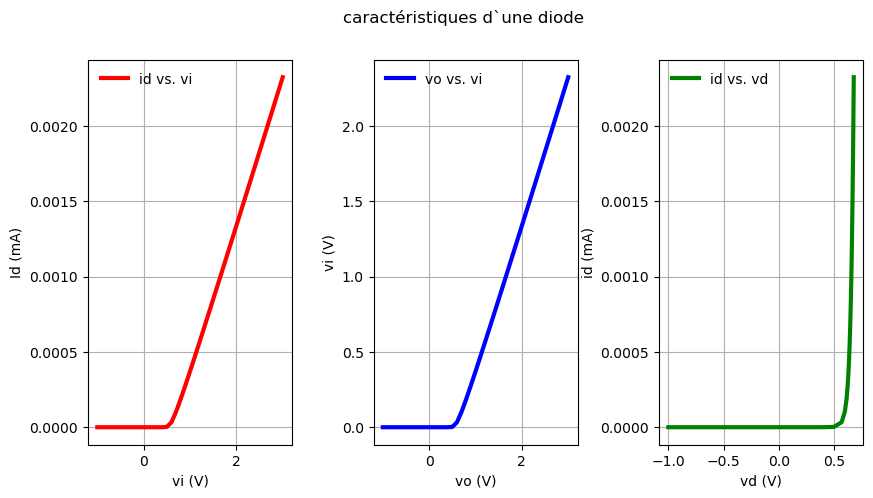

In [4]:
#exporter vos simulations en .txt et tracer les en subplot dans cette cellule
#adapter les labels des dataframes en fonctions de v
data = pd.read_csv("A1_simu.txt",  delimiter = "\t")
# print(data)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,5))
fig.suptitle('caractéristiques d`une diode')
ax1.plot(data["v1"], data["I(1n4003)"], lw=3,label = "id vs. vi", color="red")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("Id (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(data["v1"], data["V(vo)"], lw=3,label = "vo vs. vi", color="blue")
ax2.set_xlabel("vo (V)")
ax2.set_ylabel("vi (V)")
ax2.grid()
ax2.legend(frameon=False)
# ax3.semilogy(data["V(vi)"]-data["V(vo)"], data["I(1n4003gp)"], lw=3,label = "id .vs vd", color="green")
ax3.plot(data["v1"]-data["V(vo)"], data["I(1n4003)"], lw=3,label = "id vs. vd", color="green")
ax3.set_xlabel("vd (V)")
ax3.set_ylabel("id (mA)")
ax3.grid()
ax3.legend(frameon=False)
# fig.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

#Résultats

- Remplacer l'alimentation dc par un GBF et paramétrer le pour déterminer la résistance dynamique $r_d$ de la diode. Montrer que $r_d$ est égale en première approximation à $\frac{26 mV}{i_D}$. 

rd pour 3 pts de la caracteristique I_V: se placer sur un pt de polarisation et superposer un ac - extraire Di/Dv. n = 1 pour 1N4003
$$r_d = \frac{26mV}{i_d}$$


<img src="attachment:382c6aed-c4f1-440b-b645-a1ba4b14c27b.png" width="350" text-align="Figure 1" style="margin-left:auto; margin-right:auto" id="fig1">
<p style="text-align:center"><strong>Fig. 1</strong>: diode</p>

## **A2- Mesures**:  
Assembler le circuit sur une labdec et varier l'alimentation dc $V_I$ sur une plage adéquate par pas de 0.25 V. Pour chaque point, mesurer la tension de sortie $V_o$ au multimètre, et relever le courant $i_D$ débité par l'alimentation.  
- Tracer $i_D$ vs. $V_I$, $V_o$ vs. $V_I$.  
- Tracer $i_D$ vs. $V_D$ (échelle linéaire et semilog), déterminer le seuil  

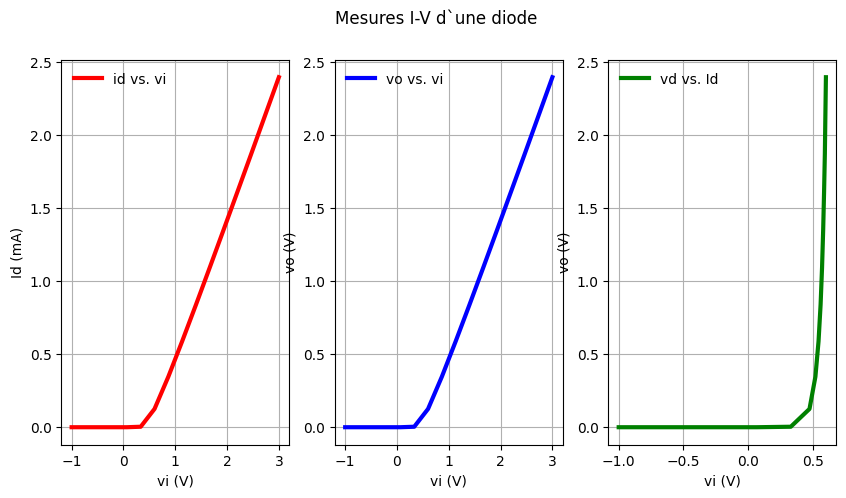

In [2]:
#TP ANA2 
# adapter les variations de tensions - celles mentionnées ne sont qu`indicatives.
#A-Diode
vi =  [-1.0, -0.7333333333333334, -0.4666666666666667, -0.19999999999999996, 0.06666666666666665, 0.33333333333333326, 0.6000000000000001, 0.8666666666666667, 1.1333333333333333, 1.4, 1.6666666666666665, 1.9333333333333331, 2.2, 2.466666666666667, 2.7333333333333334, 3.0]
vo = [] # en V
Id = [-2.928012e-09,-2.905887e-09,-2.491024e-09,-1.985021e-09,4.711629e-09,3.323518e-06,0.0001253932,0.0003463563,0.0005888303,0.0008396147,0.001094981,0.001353,0.001612707,0.001873349,0.002135987,0.002398478] # en A
for i in range(len(Id)):
    Id[i]=Id[i]*1000
for i in range(len(vi)): #R=1000ohm
    vo.append(Id[i]*1000/1000)
vd = np.subtract(vi, vo)
# plot(vd, Id, 'Id vs.vout', "mediumseagreen")
# plot(data["v1"], data["I(1n4003gp)"]/1e-3, "fit", "blue")
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,5))
fig.suptitle('Mesures I-V d`une diode')
ax1.plot(vi, Id, lw=3,label = "id vs. vi", color="red")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("Id (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(vi, vo, lw=3,label = "vo vs. vi", color="blue")
ax2.set_xlabel("vi (V)")
ax2.set_ylabel("vo (V)")
ax2.grid()
ax2.legend(frameon=False)
ax3.plot(vd, Id, lw=3,label = "vd vs. Id", color="green")
ax3.set_xlabel("vi (V)")
ax3.set_ylabel("vo (V)")
ax3.grid()
ax3.legend(frameon=False)
plt.show()

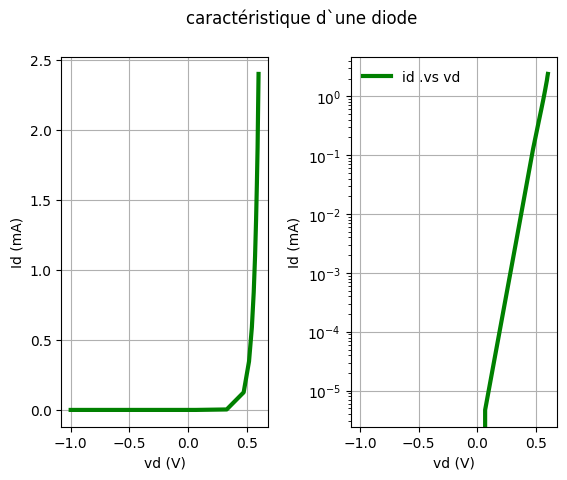

In [3]:
plot1(vd, Id, "id .vs vd", "green")
plt.show()

## **A3 - Traitement post-mesures**:  
- Déterminer la résistance statique $r_f$ de la diode pour 3 courants caractéristiques. Commenter.<br>
- Superposer vos mesures aux simulations (exporter le fichier .txt de LTspice et appeler le dans la dataframe data). <br>
- Constatez vous une différence majeure avec les simulations? (attention au modèle choisi)  

In [ ]:
#Mesure de rd
# injecter 100 mVpp au GBF autour d`un pt de polarisation en prendre 2 ou 3 (GBF + offset)
#rd = Vrms/Irms
#pts de polarisation [0.6V, 0.7V, 0.8V]
Vrms = 50e-3/np.sqrt(2)
# Idrms = [vos mesures]   # composante ac mesurée au milliamperementre
# rd = Vrms/Idrms
print("rd = ", 0.6/0.0001253932)
print("rd = ", 0.6/0.0003463563)

plt.show()

rd =  4784.94846610502


## Commentaires

# **B - CIRCUITS Á DIODES**  
**Objectifs**: analyser, simuler et mesurer diff´erents circuits á diodes e.g. détecteur de pic, ecrêteurs et limiteurs, doubleurs.  
## **B1 - Simulation**: 
On considère le circuit de la [figure 2](#fig2)
- Simuler chaque circuit avec les paramètres indiqués. <br> 
- Pour chaque simulation, tracer $V_{I}$ et $V_{o}$ en fonction du temps.

(a) - limiteur: R=1 ko, diode 1N4003, $V_{I}$ est un sinus de 5 V$_{pk-pk}$ sans offset, f=100 Hz<br>
(b) - limiteur Zener: R=1 ko, diode 1N4733A, $V_{I}$ est un sinus de 15 V$_{pk-pk}$ sans offset, f=100 Hz<br>
(c) - écreteur à capacité: $R_L$=10 ko, C=47 $\mu$F, diode 1N4003, $V_{I}$ est un carré de 2 V$_{pk-pk}$ sans offset, f=100 Hz<br>
(d) - doubleur de tension:  $R_L$=100 ko en charge, C1=C2=47 $\mu$F, diode 1N4003, $V_{I}$ est un sinus de 5 V$_{pk-pk}$ sans offset, f=100 Hz<br>

<img src="attachment:5fadbff7-e461-4078-a307-f870c1dfac04.png" width="500" text-align="Figure 2" style="margin-left:auto; margin-right:auto" id="fig2">
<p style="text-align:center"><strong>Fig. 2</strong>: circuits à diodes</p>

<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:3: SyntaxWarning: invalid escape sequence '\B'
<>:4: SyntaxWarning: invalid escape sequence '\B'
<>:5: SyntaxWarning: invalid escape sequence '\B'
<>:2: SyntaxWarning: invalid escape sequence '\B'
<>:3: SyntaxWarning: invalid escape sequence '\B'
<>:4: SyntaxWarning: invalid escape sequence '\B'
<>:5: SyntaxWarning: invalid escape sequence '\B'
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\4269088388.py:2: SyntaxWarning: invalid escape sequence '\B'
  a = pd.read_csv(path+'\B1a.txt',  delimiter = "\t")
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\4269088388.py:3: SyntaxWarning: invalid escape sequence '\B'
  b = pd.read_csv(path+'\B1b.txt',  delimiter = "\t")
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\4269088388.py:4: SyntaxWarning: invalid escape sequence '\B'
  c = pd.read_csv(path+'\B1c.txt',  delimiter = "\t")
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\4269088388.py:5: SyntaxWarning: invalid escape sequence '\B

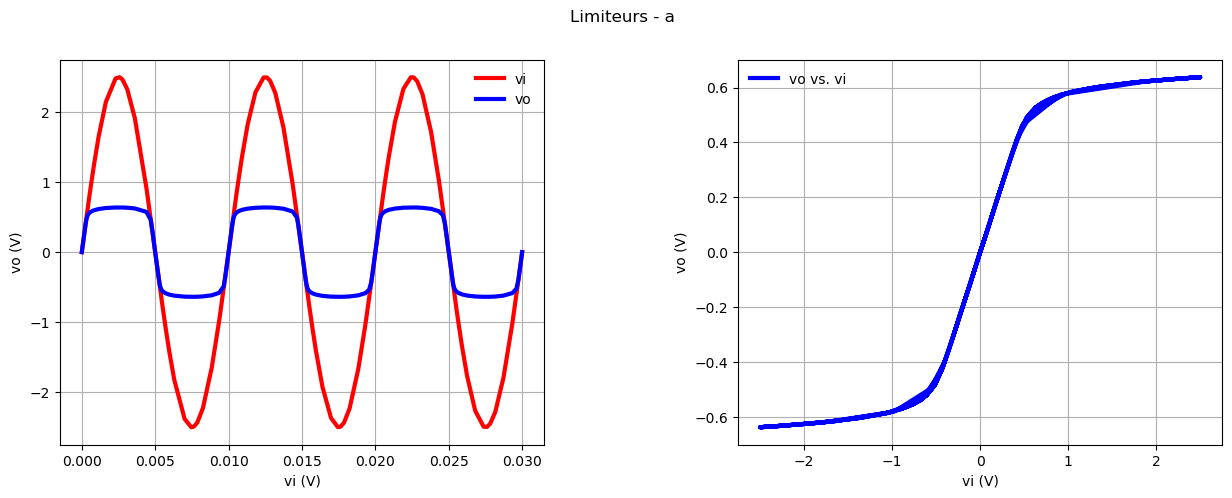

In [219]:
#exporter vos simulations en .txt et tracer les en subplot dans cette cellule
a = pd.read_csv(path+'\B1a.txt',  delimiter = "\t")
b = pd.read_csv(path+'\B1b.txt',  delimiter = "\t")
c = pd.read_csv(path+'\B1c.txt',  delimiter = "\t")
d = pd.read_csv(path+'\B1d.txt',  delimiter = "\t")

# limiteur - a
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle('Limiteurs - a')
ax1.plot(a["time"], a["V(vi)"],  lw=3,label = "vi", color="red")
ax1.plot(a["time"], a["V(vo)"],  lw=3,label = "vo", color="blue")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("vo (V)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(a["V(vi)"], a["V(vo)"],  lw=3,label = "vo vs. vi", color="blue")
ax2.set_xlabel("vi (V)")
ax2.set_ylabel("vo (V)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

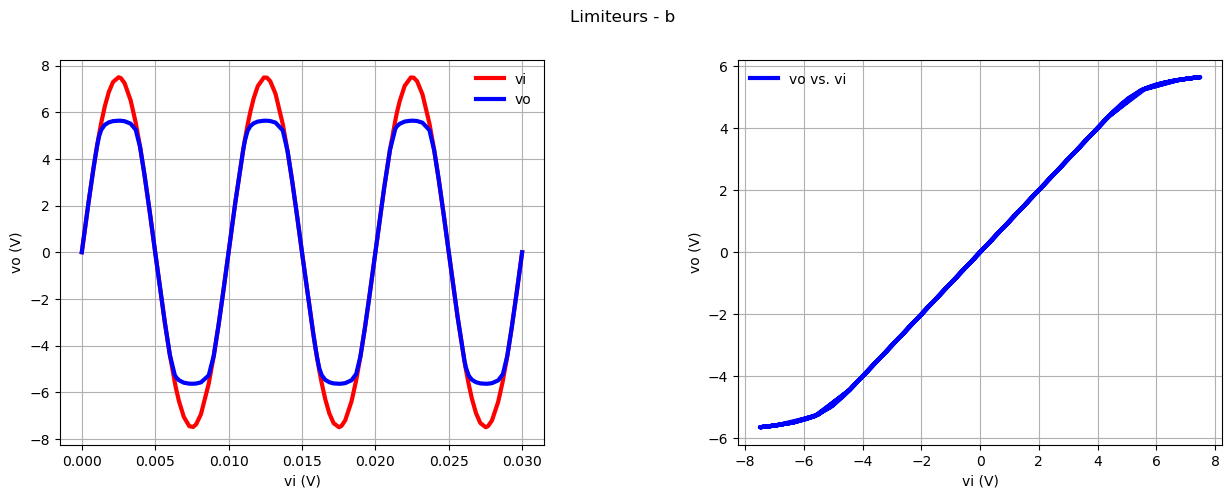

In [221]:
# limiteur - b
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle('Limiteurs - b')
ax1.plot(b["time"], b["V(vi)"],  lw=3,label = "vi", color="red")
ax1.plot(b["time"], b["V(vo)"],  lw=3,label = "vo", color="blue")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("vo (V)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(b["V(vi)"], b["V(vo)"],  lw=3,label = "vo vs. vi", color="blue")
ax2.set_xlabel("vi (V)")
ax2.set_ylabel("vo (V)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

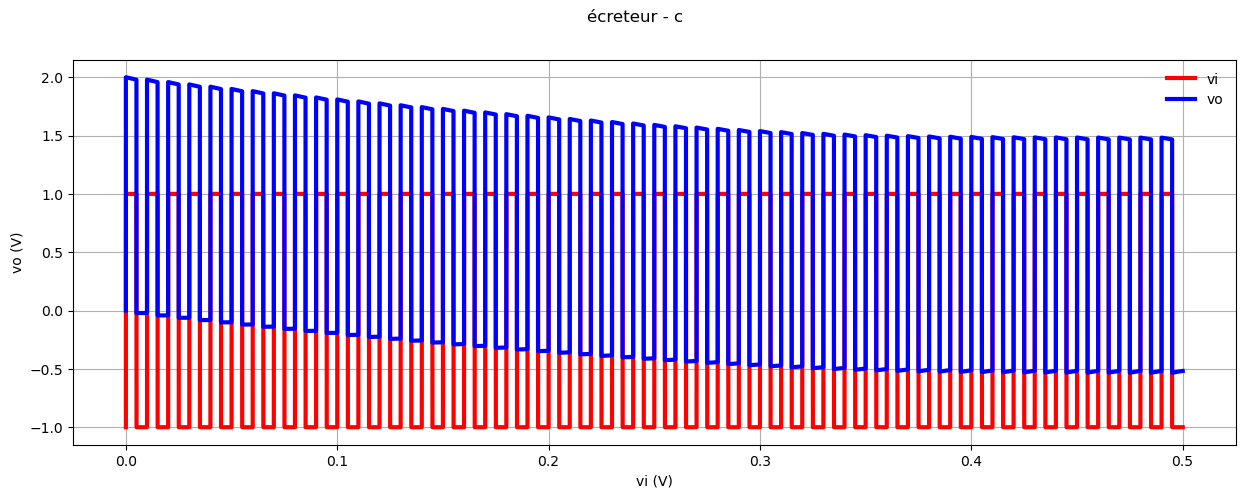

In [223]:
# ecreteur - c
fig, (ax1) = plt.subplots(1, 1, figsize=(15,5))
fig.suptitle('écreteur - c')
ax1.plot(c["time"], c["V(vi)"],  lw=3,label = "vi", color="red")
ax1.plot(c["time"], c["V(vo)"],  lw=3,label = "vo", color="blue")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("vo (V)")
ax1.grid()
ax1.legend(frameon=False)
plt.show()

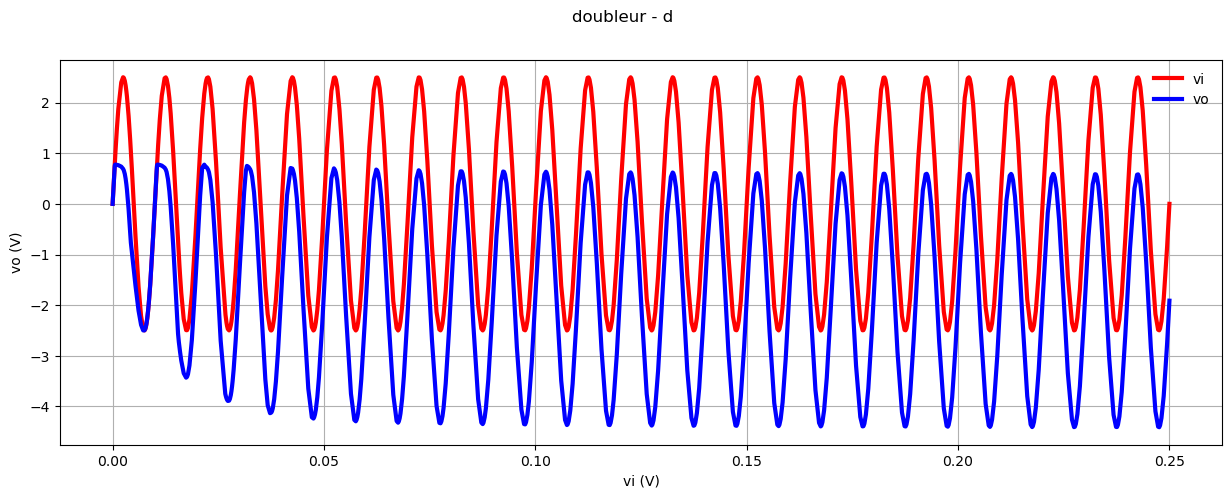

In [225]:
# doubleur - d
fig, (ax1) = plt.subplots(1, 1, figsize=(15,5))
fig.suptitle('doubleur - d')
ax1.plot(d["time"], d["V(vi)"],  lw=3,label = "vi", color="red")
ax1.plot(d["time"], d["V(vo)"],  lw=3,label = "vo", color="blue")
ax1.set_xlabel("vi (V)")
ax1.set_ylabel("vo (V)")
ax1.grid()
ax1.legend(frameon=False)
plt.show()

## **B2 - Mesures**: 
Assembler chacun des circuits et appliquer le signal en entrée spécifié dans la partie description ci-dessus
en utilisant un GBF. Mesurer la sortie avec un oscilloscope.<br>
- Pour les circuits (a - c) relever les tension minimales et maximales
- Pour les circuits limiteurs, representer en mode X-Y la tension $V_o$ vs. $V_I$

## **B3 - Traitement post mesures**: 
Commenter les fonctions réalisées et comparer avec vos simulations. <br>
- Est il possible de changer le circuit limiteur pour limiter entre +/- 1.4 V<br>
- Est il possible d‘obtenir un ecrêtage négative <br>
- Est il possible de modifier le doubleur de tension pour obtenir une tension positive

#coller ici les screenshots de l`oscillo
# Limiteur diodes - a
![Limiteur - a](B2_screen\LimiteurA.jpg "a - Limiteur")
# Limiteur diodes - b
![Limiteur - b](B2_screen\LimiteurB.jpg "b - Limiteur")
# Limiteur diodes - c
![Ecreteur - c](B2_screen\EcreteurC.jpg "c - Ecreteur")
# doubleur diodes - d 
![Doubleur - d](B2_screen\DoubleurD.jpg "d - Doubleur")

## Commentaires

# **C - CARACTÉRISTIQUES DE TRANSFERT D‘UN TRANSISTOR NMOS**  
**Objectifs**: Simuler et mesures les paramétres d'un transistor en fonction du courant de drain vs. la tension grille-source et source-drain.Extraire les paramètres : $k_n$, $V_{tn}$ et eventuellement $\lambda_n$  
**NB**: observer bien le brochage des transistors notamment le substrat (B) pour les NMOS et PMOS - choisissez judicieusement le NMOS à etudier. Vous prendrez ici un NMOS dont le substrat est connecté à la source.
## **C1 - Simulation**:  
On considère le circuit de la [figure 3](#fig3). Polariser à l'aide des alimentations dc et de résistances de polarisation le circuit et :
- Tracer $I_D$ vs. $V_{GS}$ : maintenir $V_{DS}$ constant á 5 V et balayer la tension de grille de 0 á 5 V par pas de 0.1 V. Déterminer la tension de seuil de $V_{GS}$ i.e $V_{tn}$ pour laquelle le courant augmente
- Tracer $I_D$ vs. $V_{DS}$ : pour 3 valeurs de $V_{GS}$ (2.5, 3 et 3.5 V), balayer la tension de drain de 0 á 5 V par pas de 0.1 V. Quelles informations êtes vous susceptibles d'extraire de ces caractéristiques de sortie.

<img src="attachment:0bdaf441-b6ca-431b-985d-cef2548629dc.png" width="300" text-align="Figure 3" style="margin-left:auto; margin-right:auto" id="fig3">
<p style="text-align:center"><strong>Fig. 3</strong>: Transistor MOS</p>

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\C'
<>:5: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\C'
<>:5: SyntaxWarning: invalid escape sequence '\C'
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\2948393696.py:2: SyntaxWarning: invalid escape sequence '\C'
  a = pd.read_csv(path+'\C1_MOS_Id_Vgs.txt',  delimiter = "\t")
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\2948393696.py:3: SyntaxWarning: invalid escape sequence '\C'
  b1 = pd.read_csv(path+'\C1_MOS_Id_Vds_2,5.txt',  delimiter = "\t")
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\2948393696.py:4: SyntaxWarning: invalid escape sequence '\C'
  b2 = pd.read_csv(path+'\C1_MOS_Id_Vds_3.txt',  delimiter = "\t")
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\2948393696.py:5: Synt

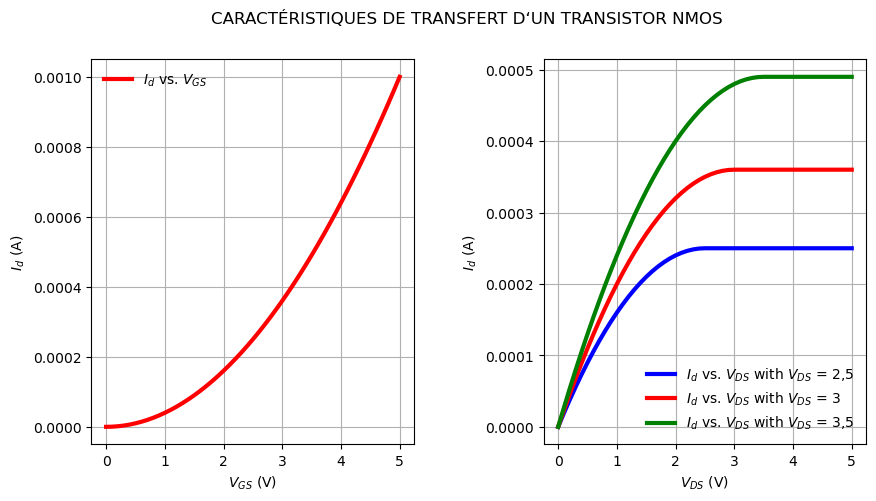

In [233]:
#exporter vos simulations en .txt et tracer les en subplot dans cette cellule
a = pd.read_csv(path+'\C1_MOS_Id_Vgs.txt',  delimiter = "\t")
b1 = pd.read_csv(path+'\C1_MOS_Id_Vds_2,5.txt',  delimiter = "\t")
b2 = pd.read_csv(path+'\C1_MOS_Id_Vds_3.txt',  delimiter = "\t")
b3 = pd.read_csv(path+'\C1_MOS_Id_Vds_3,5.txt',  delimiter = "\t")
# NMOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('CARACTÉRISTIQUES DE TRANSFERT D‘UN TRANSISTOR NMOS')
ax1.plot(a["V(vgs)"], -a["Id(M1)"],  lw=3,label = "$I_d$ vs. $V_{GS}$", color="red")
ax1.set_xlabel("$V_{GS}$ (V)")
ax1.set_ylabel("$I_d$ (A)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(b1["V(vds)"], -b1["Id(M1)"],  lw=3,label = "$I_d$ vs. $V_{DS}$ with $V_{DS}$ = 2,5", color="blue")
ax2.plot(b2["V(vds)"], -b2["Id(M1)"],  lw=3,label = "$I_d$ vs. $V_{DS}$ with $V_{DS}$ = 3", color="red")
ax2.plot(b3["V(vds)"], -b3["Id(M1)"],  lw=3,label = "$I_d$ vs. $V_{DS}$ with $V_{DS}$ = 3,5", color="green")
ax2.set_xlabel("$V_{DS}$ (V)")
ax2.set_ylabel("$I_d$ (A)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

In [235]:
#Traitement des simulations -  extraire k_n, V_tn et 1/Va = lambda
# print(a)
# Determiner Vt et kn prendre les données pour id vs. vgs  pour 1 Vds assurant la saturation  
#tracer sqrt(Id) vs. vgs

## **C2 - Mesures**: 
Assembler le circuit de la [figure 3](#fig3) avec les 2 alimentations dc connectées à la grille et au drain puis tracer:
- $I_D$ vs. $V_{GS}$ : maintenir VDS constant á 5 V et balayer la tension de grille de 0 á 3.5 V par pas de 0.25 V (on réduit le nombre de points par rapport aux simulations) et mesurer le courant de drain débité par l‘alimentation. Identifier la tension de seuil.
- $I_D$ vs. $V_{DS}$ : pour 3 valeurs de $V_{GS}$ (2.5, 3 et 3.5 V), balayer la tension de drain de 0 á 3.5 V par pas de 0.5 V et mesurer $I_D$.

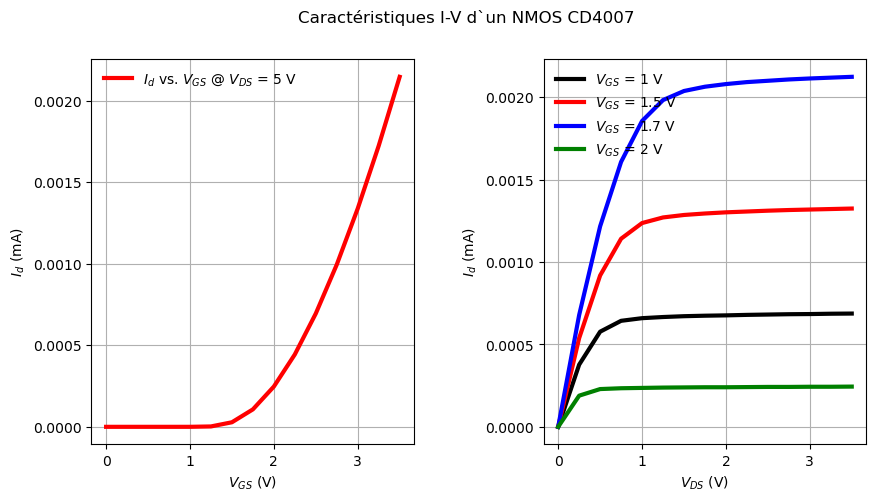

In [238]:
#IV NNOS
# mesures Id vs Vgs
Vds = 5
Vgs =  [0.0,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.25,3.5]  # en V
Id =   [0.0000000005111439,0.000000000546174,0.0000000005115756,0.000000001652339,0.00000005750962,0.000002318928,0.00002789848,0.0001070000,0.0002470000,0.0004440000,0.0006950000,0.0009950000,0.001339000,0.001724000,0.002147000] # en V
# mesures Id vs Vds
Vgs_1 = 2.5
Vgs_2 = 3
Vgs_3 = 3.5
Vgs_4 = 2

Vds_1 =  [0.0,0.25,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.25,3.5]  # en V
Id_1 =   [-0.00000001914666,0.0003770000,0.00057700,0.0006430000,0.000659000,0.000666000,0.0006710000,0.0006740000,0.0006760000,0.000679000,0.0006810000,0.0006830000,0.0006840000,0.00068600,0.0006870000] # en A
Vds_2 =  Vds_1  # en V
Id_2 =   [-0.00000001613223,0.0005380000,0.0009180000,0.001141000,0.00123600,0.001270000,0.001285000,0.001294000,0.001301000,0.001306000,0.001311000,0.00131500,0.001318000,0.001321000,0.001324000] # en A
Vds_3 =  Vds_1  # en V
Id_3 =   [-0.00000001011384,0.0006780000,0.001216000,0.001607000,0.001855000,0.001982000,0.002037000,0.002063000,0.002079000,0.002091000,0.002099000,0.002107000,0.002113000,0.002118000,0.00212300] # en A
Vds_4 =  Vds_1  # en V
Id_4 =   [-0.00000002814933,0.0001890000,0.0002290000,0.0002340000,0.0002360000,0.0002380000,0.0002390000,0.000240000,0.0002400000,0.0002410000,0.0002420000,0.0002420000,0.0002430000,0.000243000,0.0002440000] # en A

#courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('Caractéristiques I-V d`un NMOS CD4007')
ax1.plot(Vgs, Id,  lw=3,label = "$I_d$ vs. $V_{GS}$ @ $V_{DS}$ = 5 V", color="red")
ax1.set_xlabel("$V_{GS}$ (V)")
ax1.set_ylabel("$I_d$ (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(Vds_1,Id_1,lw=3,label = '$V_{GS}$ = 1 V', color="black")
ax2.plot(Vds_2,Id_2,lw=3,label = '$V_{GS}$ = 1.5 V', color="red")
ax2.plot(Vds_3,Id_3,lw=3,label = '$V_{GS}$ = 1.7 V', color="blue")
ax2.plot(Vds_4,Id_4,lw=3,label = '$V_{GS}$ = 2 V', color="green")
ax2.set_xlabel("$V_{DS}$ (V)")
ax2.set_ylabel("$I_d$ (mA)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

## **C3 - Traitement post-mesures :** 
- Comparer vos résultats de simulations et vos mesures - observez vous des différences majeures
- Determiner les paramétres $k_n$, $V_{tn}$ et eventuellement $\lambda_n$ et comparer les avec ceux extraits de vos simulations 


## Commentaires

## Reproduire pour un PMOS

# **D - CARACTÉRISTIQUES DE TRANSFERT D‘UN TRANSISTOR BJT**  
**Objectifs**: 
- Simuler un transistor BJT [figure 4](#fig4) et étudier l‘évolution du courant collecteur vs. la tension ´emetteur-base et collecteur-´emetteur
- Assembler un circuit et mesurer $I_C$ vs. $V_{BE}$ et $I_C$ vs. $V_{CE}$
- Extraire les param`etres : β, $V_A$

<img src="attachment:1c426d7d-97d5-45f1-91f8-024eb47f9d56.png" width="300" text-align="Figure 4" style="margin-left:auto; margin-right:auto" id="fig4">
<p style="text-align:center"><strong>Fig. 4</strong>: Transistor BJT</p>

## **D1 - Simulation**:  
Simuler ce circuit en placant 2 alimentations dc sur la base et le collecteur du transistor. Tracer:
- $I_C$ vs. $V_{BE}$: maintenir  $V_{CE}$ constante á 5 V et balayer $V_{BE}$ de 0 á 0.8 V par pas de 0.1 V. Déterminer la tension de seuil.
- Que valent les courants $I_C$ et $I_B$ lorsque  $V_{BE}$ = 0.7 V? calculer β
- $I_C$ vs. $V_{CE}$ : pour 3 valeurs de  $V_{BE}$ (0.6, 0.7 et 0.8 V ajuster pour avoir des tracés fins), balayer  $V_{CE}$ de 0 à 2 V par pas de 0.1 V. 

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\4188612497.py:2: SyntaxWarning: invalid escape sequence '\D'
  a = pd.read_csv(path+'\D1_Ic_Vbe.txt',  delimiter = "\t")
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\4188612497.py:3: SyntaxWarning: invalid escape sequence '\D'
  b1 = pd.read_csv(path+'\D1_Ic_Vce_0,6.txt',  delimiter = "\t")
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\4188612497.py:4: SyntaxWarning: invalid escape sequence '\D'
  b2 = pd.read_csv(path+'\D1_Ic_Vce_0,7.txt',  delimiter = "\t")
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\4188612497.py:5: SyntaxWarning:

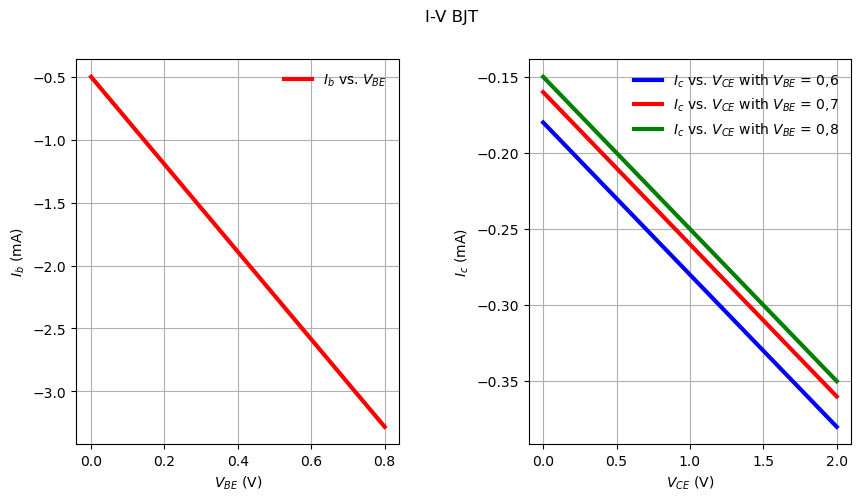

In [246]:
#exporter vos simulations en .txt et tracer les en subplot dans cette cellule
a = pd.read_csv(path+'\D1_Ic_Vbe.txt',  delimiter = "\t")
b1 = pd.read_csv(path+'\D1_Ic_Vce_0,6.txt',  delimiter = "\t")
b2 = pd.read_csv(path+'\D1_Ic_Vce_0,7.txt',  delimiter = "\t")
b3 = pd.read_csv(path+'\D1_Ic_Vce_0,8.txt',  delimiter = "\t")
# NMOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('I-V BJT')
ax1.plot(a["V(vbe)"], a["Ib(Q1)"],  lw=3,label = "$I_b$ vs. $V_{BE}$", color="red")
ax1.set_xlabel("$V_{BE}$ (V)")
ax1.set_ylabel("$I_b$ (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(b1["V(vce)"], b1["Ic(Q1)"],  lw=3,label = "$I_c$ vs. $V_{CE}$ with $V_{BE}$ = 0,6", color="blue")
ax2.plot(b2["V(vce)"], b2["Ic(Q1)"],  lw=3,label = "$I_c$ vs. $V_{CE}$ with $V_{BE}$ = 0,7", color="red")
ax2.plot(b3["V(vce)"], b3["Ic(Q1)"],  lw=3,label = "$I_c$ vs. $V_{CE}$ with $V_{BE}$ = 0,8", color="green")
ax2.set_xlabel("$V_{CE}$ (V)")
ax2.set_ylabel("$I_c$ (mA)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

## **D2 - Mesures**:  
Assembler le circuit et mesurer:
- $I_b$ vs. $V_{BE}$ : maintenir $V_{CE}$ constante à 5 V et balayer la tension de base de 0 à 0.8 V par pas de 0.1 V et mesurer $I_b$ vs. $V_{BE}$. Tracer la caractétistique et déterminer la tension de seuil de VBE pour laquelle le courant augmente
- Mesurer $I_b$ et $I_c$ pour $V_{BE}$ = 0.7 V et calculer β
- $I_c$ vs. $V_{CE}$ : pour 3 valeurs de $V_{BE}$ (0.6, 0.7 et 0.8 V), balayer $V_{CE}$ de 0 à 1 V par pas de 0.1 V et mesurer $I_c$.

In [54]:
#IV BJT   mettre des resistances 100k et 1k comme simulation
#Ic vs Vbe
Vce = 5
Vbe =  [vos mesures]  # en V
Ib =   [vos mesures] # en V

#mesure du courant ib et ic
ic_beta = xxx
ib_beta = xxx
beta = ic_beta/ib_beta
print("beta = ", beta) # attention peut varier selon le composant attention à la comparaison avec SPICE

# Ic vs Vce
Vbe_1 = xx
Vbe_2 = xx
vbe_3 = xx
vbe_4 = xx

Vce_1 =  [vos mesures]  # en V
Ic_1 =   [vos mesures] # en V
Vce_2 =  [vos mesures]  # en V
Ic_2=   [vos mesures] # en V
Vce_3 =  [vos mesures]  # en V
Ic_3 =   [vos mesures] # en V
# Vce_4 =  [vos mesures]  # en V
# Ic_4 =   [vos mesures] # en V

#courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('Caractéristiques I-V d`un BJT CA3046')
ax1.plot(Vbe, Ib,  lw=3,label = "$I_b$ vs. $V_{BE}$ @ $V_{CE}$ = 5 V", color="red")
ax1.set_xlabel("$V_{BE}$ (V)")
ax1.set_ylabel("$I_b$ (mA)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(Vce_1,Ic_1,lw=3,label = '$_{Vbe}$ = 0.5 V', color="black")
ax2.plot(Vce_2,Ic_2,lw=3,label = '$_{Vbe}$ = 0.6 V', color="red")
ax2.plot(Vce_3,Ic_3,lw=3,label = '$_{Vbe}$ = 0.7 V', color="blue")
# ax2.plot(Vce_4,Ic_4,lw=3,label = '$_{Vbe}$ = 0.7 V', color="green")
ax2.set_xlabel("$V_{CE}$ (V)")
ax2.set_ylabel("$I_c$ (mA)")
ax2.grid()
ax2.legend(frameon=False)
plt.subplots_adjust(wspace=0.4, hspace=0.5)
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2236125981.py, line 4)

## **D3 - Traitement post-mesures**:  

- Observez vous des differences entre le modèle simulé et la mesure?
- Est il possible de de déterminer la tension de Early?

# **E - AMPLIFICATEUR NMOS SOURCE COMMUNE (CS)**  
**Objectifs**: 
- Analyse DC et petit signal - étude théorique
- Simulation et comparaison avec la préparation
- Assembler le circuit et mesurer les performances de l‘amplificateur - comparaison avec la simulation
- Mesure de la résistance de sortie
- Évaluer qualitativement l‘impact des variations entre transistors

## **E1 - Dimensionnement et simulation**:  
On considère le circuit de la [figure 5](#fig5), on souhaite dimensionner l‘amplificateur pour un gain petit signal $A_v$=-5V/V. On prendra $V_+$ = $V_−$ = 15 V, $R_{sig}$ = 50 $\Omega$, $R_L$ = 10 k$\Omega$, $R_G$ = 10 k$\Omega$ et on concevra le circuit pour un courant $I_D$ = 1 mA.

<img src="attachment:ab88d2bc-9804-4bc1-ba42-395d39a9882c.png" width="350" text-align="Figure 5" style="margin-left:auto; margin-right:auto" id="fig5">
<p style="text-align:center"><strong>Fig. 5</strong>: Circuit amplificateur CS</p>

**Analyse DC et point de fonctionnement**:
- Schématiser un modèle DC: remplacer les capacités de couplages $C_{C1}, C_{C2}, C_{C3}$ par des circuits ouverts (pour simplifier on omettra $v_{sig}, R_{sig}, R_{L}$) - quel est le courant dc traversant $R_G$
- Vous pouvez maintenant déduire $V_{OV}=V_{GS}-V_{tn}$ et la valeur de $g_m$ - que vaut $V_{GS}$. NB: votre transistor a en réalité une valeur de $V_{tn}$ qui varie un peu de sa valeur nominale ce qui affectera vos mesures:
- Calculer $r_o$
- Les calculs précédents vous permettent de déterminer $R_S$. Si cette valeur n'existe pas dans la série de résistance de la salle TP, assembler plusieurs résistances pour vous en approcher. NB: à ce stade vous n'avez déterminer ni $V_{DS}$ ni $R_D$

**Résultats intermédiaires**:
mettre dans cette cellule les valeurs calculées - montrer à votre encadrant votre préparation
- on remplace les capacités par des interuupteurs ouverts et la resistance R$_g$ est connecté à la masse donc I$_g$=0 ;
- on a en sqturqtion I$_d$ = $\frac{1}{2} \cdot \frac{W}{L} \cdot k' \cdot (V_{OV})^2$ donc $V_{OV} = \sqrt{ \frac{2I_D}{\left(\frac{W}{L}\right) \cdot k'} }=0.68V$. Puis g$_m$ = $\frac{dI_d}{dV_{gs}} = k_n \cdot V_{OV} = 1{,}08 \times 10^{-3} \cdot 0{,}68 = 7{,}34 \times 10^{-4}\,\text{S}$. On a V$_{ov}$=V$_{gs}$-V$_{tn}$ donc V$_{gs}$=V$_{ov}$+V$_{tn}$
- On a $r_0$ = $\frac{1}{\lambda \cdot I_D} = \frac{Va}{\lambda} = \frac{1}{10^{-2} \cdot 10^{-3}} = 100\,\text{k}\Omega$
- D'apres une loi des mailles, on a $V_{-}=V_{gs}- R_{s} \cdot I_{s}$
- 


**Analyse AC**:
- Remplacer le transistor par son modèle petit signal, les capacités sont court circuitées (qu'advient il de $R_S$?) et en remplaçant $V_+$ par une masse (qu'advient il de $V_-$?) - nommer le signal sur la grille du transistor $v_i$ i.e. tension d'entrée petit signal.
- Calculer le rapport $v_i/v_{sig}$ -  comment l'approximer?
- Déduire une expression pour $A_v=v_o/v_i$ - quelle est la valeur de $R_D$ qui produit un gain en tension petit signal $A_v$ d'au moins 5V/V?
- Quelle est la tension dc au drain - satisfait elle à la condition de saturation du transistor - commenter
- Quelle est la résistance de sortie $R_o$


**Résultats intermédiaires**:
mettre dans cette cellule les valeurs calculées - montrer à votre encadrant votre préparation
- On calcule la resistance equivalentte de R0//Rd//Rl et on a $R_{eq}=\frac{R_{0} \cdot R_{D} \cdot R_{L}}{R_{0} \cdot (R_{L}+R_{D}) + R_{L}\cdot R_{D}}$. de plus, $V_{0}=-R_{eq} \cdot I_{D}=-R_{eq} \cdot g_{m} \cdot v_{i}$ donc $A_v=v_o/v_i=-\frac{R_{0} \cdot R_{D} \cdot R_{L}}{R_{0} \cdot (R_{L}+R_{D}) + R_{L}\cdot R_{D}} \cdot g_{m}$. Pour trouver Rd, on resout $A_v=5$ donc $\frac{R_{0} \cdot R_{D} \cdot R_{L}}{R_{0} \cdot (R_{L}+R_{D}) + R_{L}\cdot R_{D}} \cdot g_{m}=5$ soit pour $R_{D}=2128\Omega$

**Simulation**:
- Simuler le circuit avec $C_{C1}=C_{C2}=C_{S}=47\mu F$ et les valeurs de $R_S$ et $R_D$ déterminées dans les analyses précédentes. Injecter un signal $v_{sig}$ de 10 $mV_{pk-pk}$/1 kHz sans offset dc.
- De vos simulations, relever les valeurs dc de $V_{GS}, V_{DS}, I_D$ -  comparer à vos calculs.
- Relever $A_v$ - est il proche de vos calculs?

**Résultats de simulation**:
mettre dans cette cellule les valeurs issues de vos simulations - montrer à votre encadrant votre préparation

<>:1: SyntaxWarning: invalid escape sequence '\E'
<>:1: SyntaxWarning: invalid escape sequence '\E'
C:\Users\sulla\AppData\Local\Temp\ipykernel_9812\798796409.py:1: SyntaxWarning: invalid escape sequence '\E'
  a = pd.read_csv(path+'\E1.txt',  delimiter = "\t")


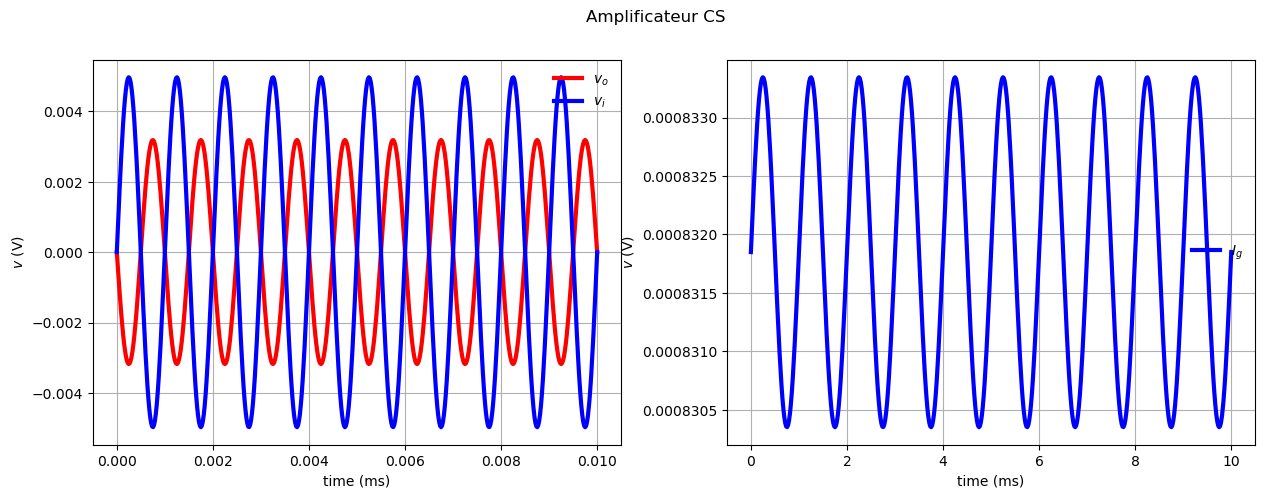

In [80]:
a = pd.read_csv(path+'\E1.txt',  delimiter = "\t")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle('Amplificateur CS')
ax1.plot(a["time"], a["V(vo)"],  lw=3,label = "$v_o$", color="red")
ax1.plot(a["time"], a["V(Vgs)"],  lw=3,label = "$v_i$", color="blue")
ax1.set_xlabel("time (ms)")
ax1.set_ylabel("$v$ (V)")
ax1.grid()
ax1.legend(frameon=False)
ax2.plot(1000*a["time"], a["Ig"],  lw=3,label = "$I_g$", color="blue")
ax2.set_xlabel("time (ms)")
ax2.set_ylabel("$v$ (V)")
ax2.grid()
ax2.legend(frameon=False)
plt.show()

## **E2 - Prototypage**:  
Assembler le circuit sur labdec que vous venez de dimensionner - $R_{sig}$ représente la résistance de sortie de votre générateur de fonction et ne doit donc pas être incluse dans votre circuit

## **E3 - Mesures**:  
- **Mesure du point de fonctionnement**: Mesurer au multimetre les tensions $V_G$, $V_D$ et $V_S$ du transistor
- **Mesure AC**: A l'aide d'un GBF injecter un signal de 10 $mV_{pk-pk}$/1 kHz sans offset dc
- A l'oscilloscope, visualiser $v_o$ et $v_i$ en fonction du temps
![Vo](E2_screen\4.jpeg "d - Doubleur")


- **Résistance de sortie $R_o$**: remplacer $R_L$ par une résistance de 1M$\Omega$ et refaire les mesures ac - Quelle est l'amplitude du signal de sortie. Ajuster $R_L$ pour obtenir une amplitude de 50\% la valeur précédente. Cette nouvelle valeur de $R_L$ représente votre résistance $R_o$. Comparer la avec celle calculée ($R_o$ ne peut pas être plus grande que $R_D$).
On a remplacer $R_L$ par une résistance de 1M$\Omega$ et on a : 
![Vo pour RL=970kohm](E2_screen\2.jpeg "d - Doubleur")
Puis pour obtenir une amplitude de 50\% la valeur précédente, on doit avoir RL=R0=8kohm et on a :
![Vo pour RL=R0=8kohm](E2_screen\3.jpeg "d - Doubleur")

- Qu'advient il au signal de sortie si on augmente le signal d'entrée e.g. 1 $V_{pk-pk}$? - A quelle amplitude commence t-on à observer de fortes distorsions du signal de sortie - expliquer.
On a augmenter notre Vsig jusqu'à voir une saturation. On a ici Vo pour Vsig=2,5Vpp.
![Vo pour Vsig=2,5Vpp](E2_screen\4.jpeg "d - Doubleur")

**Traitement post-mesures**:
- Calculer $V_{GS}$ et $V_{DS}$ obtenues. Comparer avec les calculs et expliquer les différences.
A l'aide d'un multimetre, on a trouvé Vg=0V , Vs=-2.7V et Vd=12.8V
- A partir des mesure de $V_D$ et $V_S$, et des résistances du circuits, quelle est la valeur réelle de $I_D$
- Quelle est la valeur de $A_v$ mesurée? comparer à vos calculs et expliquer les différences.

# **F - NMOS vs. NPN: COMPARAISON AMPLIFICATEUR SOURCE COMMUNE (CS)/ÉMETTEUR COMMUN (CE)**  
**Objectifs**: 
- assembler et comparer les performances d'un amplificateur CS (NMOS) et CE (BJT)
On considère les 2 circuits de la [figure 6](#fig6), remarquer les similarités entre les 2. Le travail effectué pour le CS en partie E demeure valable.

<img src="attachment:87a74b9b-2d8e-4e70-a528-7702916772fe.png" width="500" text-align="Figure 6" style="margin-left:auto; margin-right:auto" id="fig6">
<p style="text-align:center"><strong>Fig. 6</strong>: Circuits amplificateurs (a) - CS et (b) - CE</p>

## **F1 - Dimensionnement du CE et Mesures**:  

**Dimensionnement**: 
- Nous avons inter changé le NMOS avec un BJT NPN et modifié les notations. On fixe $R_E=R_S$, $R_C=R_D$ et $C_E=C_S$. On maintient les valeurs mesurées pour le CS: $V_E=V_S$ et $I_D=I_E$.
- Quel potentiel $V_B$ est nécessaire sur la base du BJT (NB: un NPN à un $V_{BE}$ de 0.7 V).
- Quelles valeurs de R1 et R2 faut il choisir pour atteindre ce potentiel $V_B$ tout en maintenant R1//R2=10 k$\Omega$? (comme $I_B$$\neq$0, il faut considérer le schéma équivalent de Thevenin)

**Résultats intermédiaires**:
mettre dans cette cellule les valeurs calculées - montrer à votre encadrant votre préparation

## **F2 - Simulation**:
- Simuler le circuit CE en utilisant les calculs précédents. Quel est le gain en tension de ce nouveau circuit? Que valent $V_B, V_C, V_E$? comparer les avec $V_G, V_D, V_S$ du circuit CS

**Résultats de simulation**:
mettre dans cette cellule les valeurs relevées - montrer à votre encadrant votre préparation

In [186]:
a = pd.read_csv(path+'\xxxxx.txt',  delimiter = "\t")
fig, (ax1) = plt.subplots(1, 1, figsize=(5,5))
fig.suptitle('Amplificateur CS')
ax1.plot(1000*a["time"], a["V(vout)"]*1000,  lw=3,label = "$v_{out}$", color="red")
ax1.plot(1000*a["time"], a["V(vin)"]*1000,  lw=3,label = "$v_{in}$", color="blue")
ax1.set_xlabel("time (ms)")
ax1.set_ylabel("$v$ (mV)")
ax1.grid()
ax1.legend(frameon=False)
plt.show()

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 0-1: truncated \xXX escape (1549314991.py, line 1)

## **F3 - Mesures**:
- Assembler le circuit CE sur labdec avec les composants calculés. Vous ne devriez avoir qu'à inter changer le NMOS avec le BJT et remplacer les nouvelles valeurs de R1 et R2
**Mesures**:
- Avec un multimetre, mesurer les tensions dc du circuit à la base $V_B$, l'émetteur $V_E$ et au collecteur $V_C$ du BJT. Ensuite injecter avec un GBF, un sinus de 50 $mV_{pk-pk}$/1 kHz sans offset dc à l'entrée. A l'oscilloscope relever: $v_o$ et $v_i$ en fonction de t.
- Déterminer $A_v$

**RESULTATS**